In [ ]:
!pip install ultralytics -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [ ]:
!pip install roboflow -q

from roboflow import Roboflow
from getpass import getpass

api_key = getpass('Masukkan Roboflow API Key: ')
rf = Roboflow(api_key=api_key)

project = rf.workspace("fruitsdetection").project("fruits-by-yolo")
version = project.version(1)
dataset = version.download("yolov8", location="/content/dataset_clean")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00
Masukkan Roboflow API Key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_clean in yolov8:: 100%|██████████| 5960/5960 [00:00<00:00, 8645.32it/s]


In [ ]:
print(open('/content/dataset_clean/data.yaml').read())

names:
- Apple
- Banana
- Grapes
- Kiwi
- Mango
- Orange
- Pineapple
- Sugerapple
- Watermelon
nc: 9
roboflow:
  license: CC BY 4.0
  project: fruits-by-yolo
  url: https://universe.roboflow.com/fruitsdetection/fruits-by-yolo/dataset/1
  version: 1
  workspace: fruitsdetection
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
results = model.train(
    data='/content/dataset_clean/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    mosaic=1.0,
    copy_paste=0.3,
    scale=0.5,
    patience=20,
    name='fruit_detector_final'
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_clean/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_detector_final, nbs=64, nms=None, ops

In [ ]:
metrics = model.val()

print("=== Overall Metrics ===")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP75: {metrics.box.map75:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

print("\n=== Per-Class Metrics ===")
for i, name in enumerate(model.names.values()):
    print(f"{name}: AP50={metrics.box.ap50[i]:.3f}, AP50-95={metrics.box.ap[i]:.3f}")

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,129,067 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1315.6±501.7 MB/s, size: 33.4 KB)
val: Scanning /content/dataset_clean/valid/labels.cache... 187 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 60.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 390, len(boxes) = 394. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.5it/s 4.9s
                   all        187        394      0.784      0.742      0.752        0.6
                 Apple         16         20      0.913          1      0.995      0.925
                Banana         27  

Confusion Matrix:


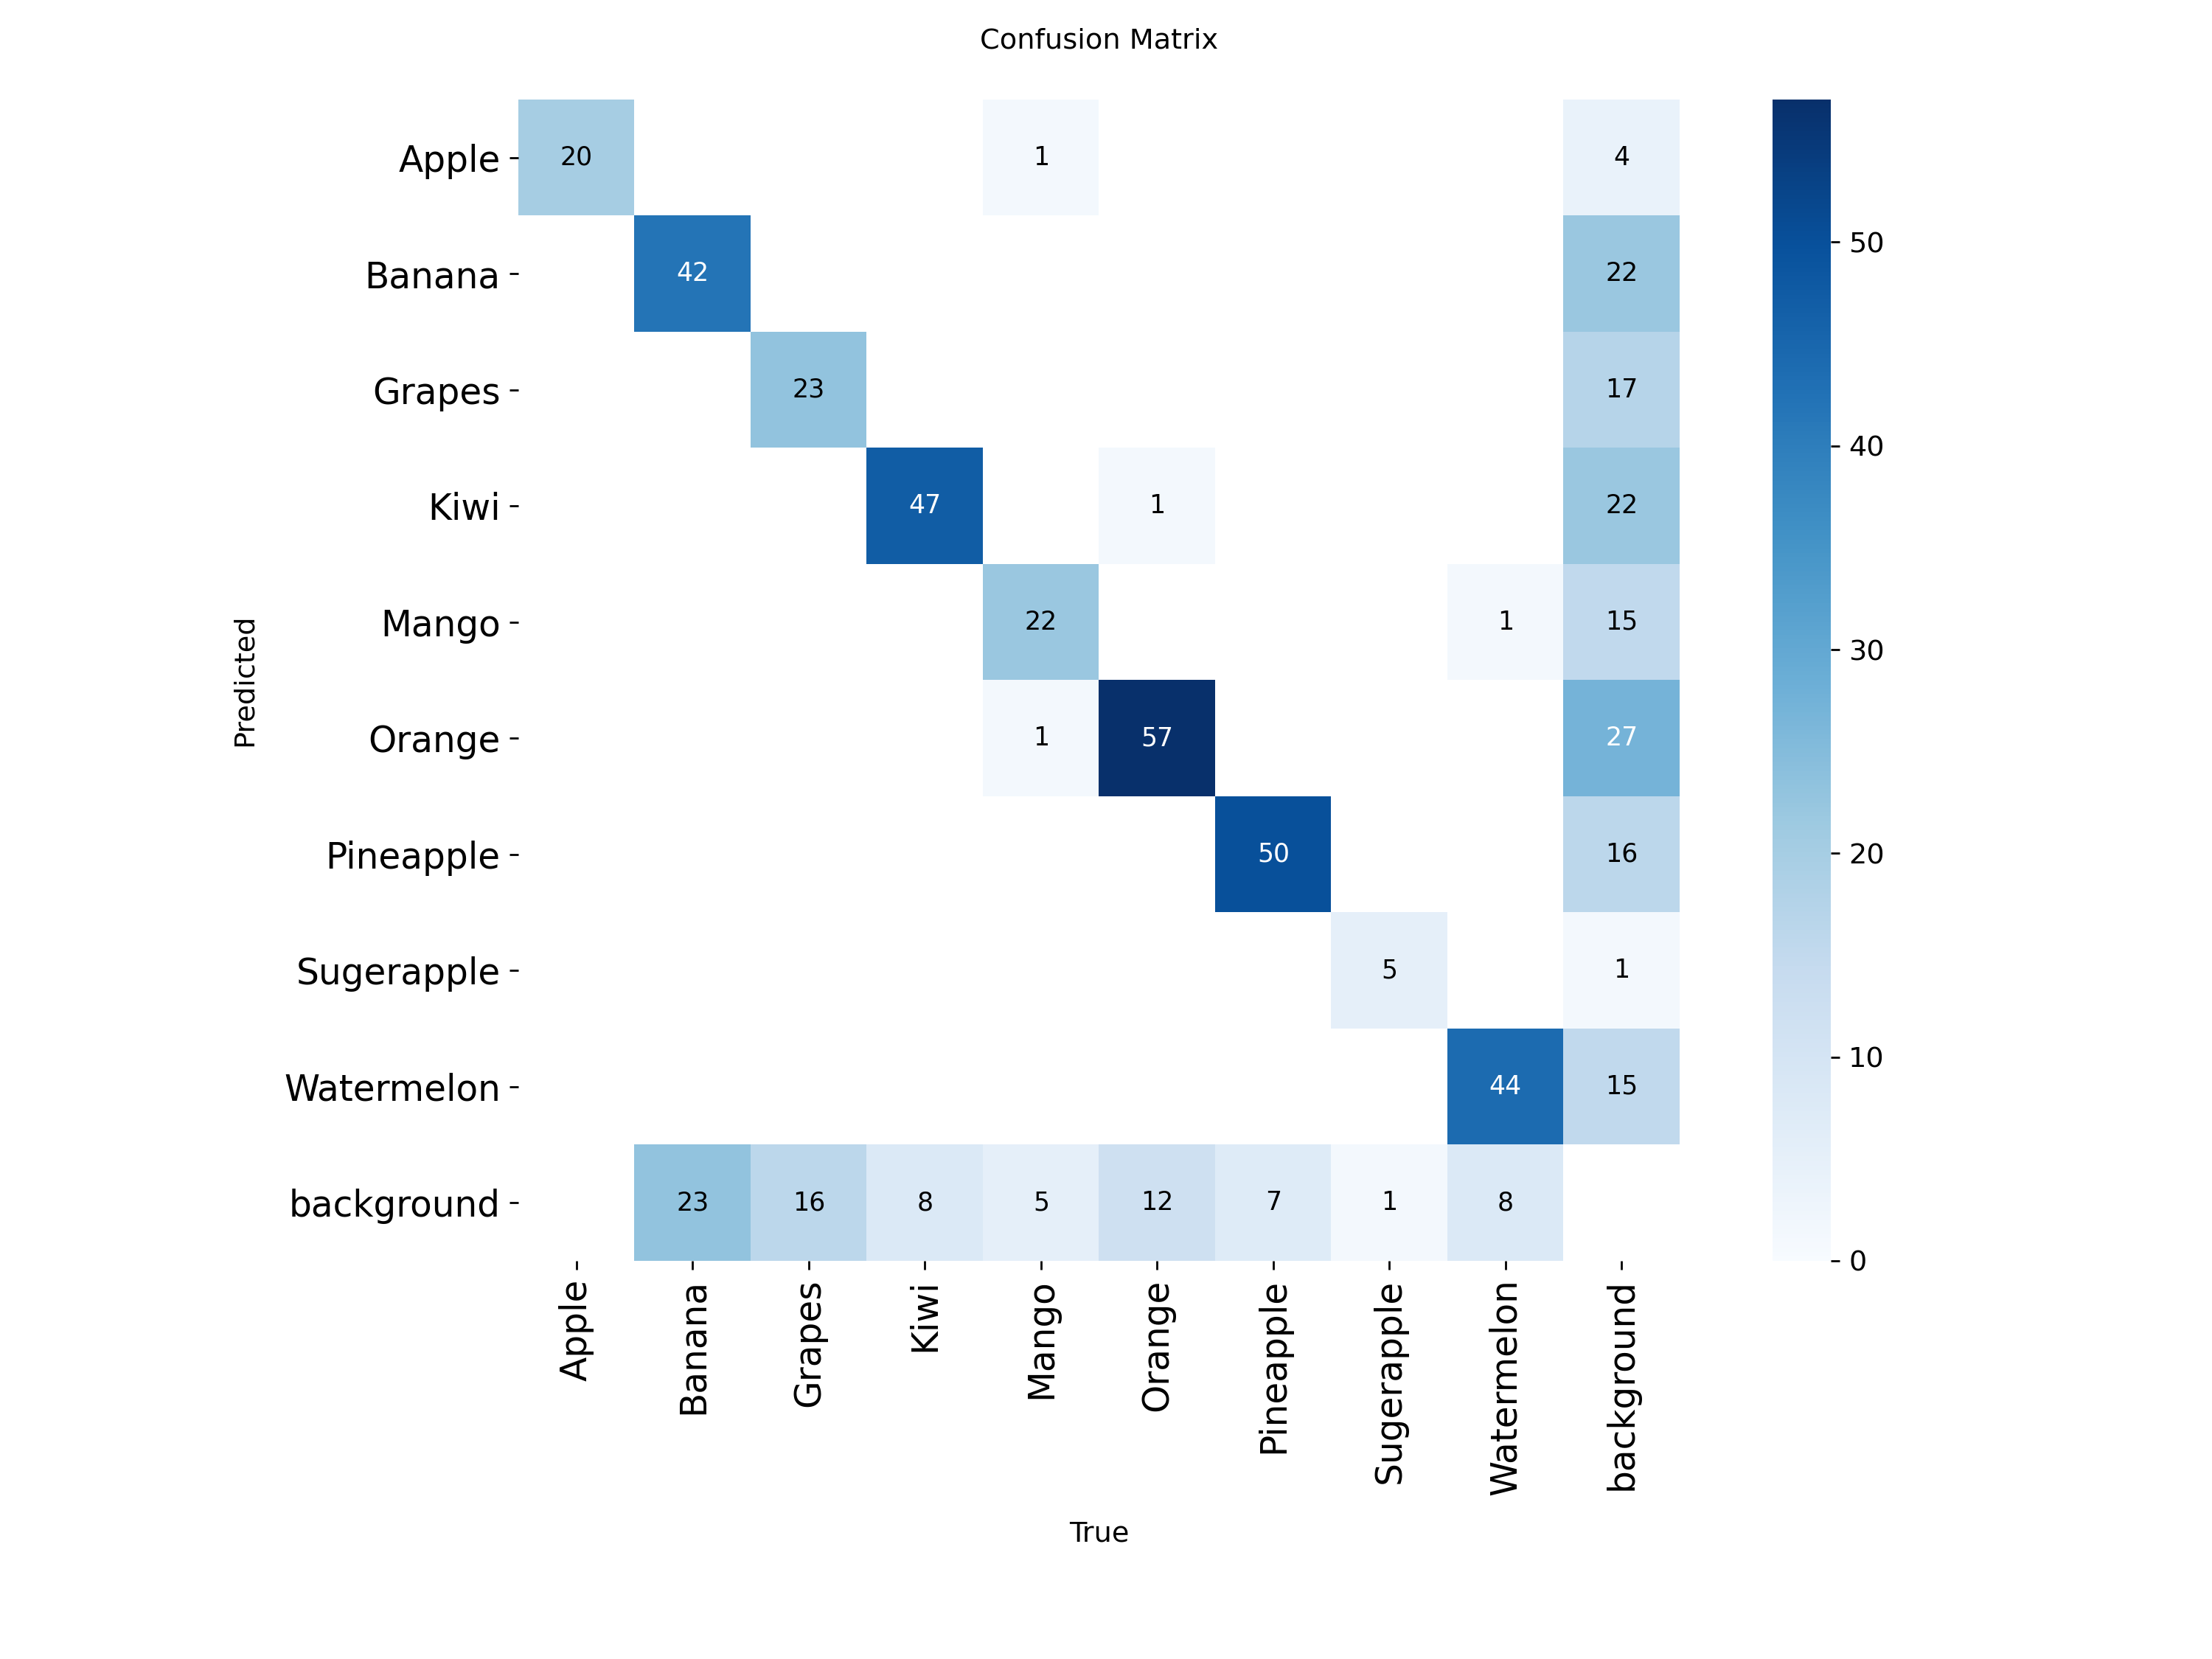

Training Curves (loss, mAP per epoch):


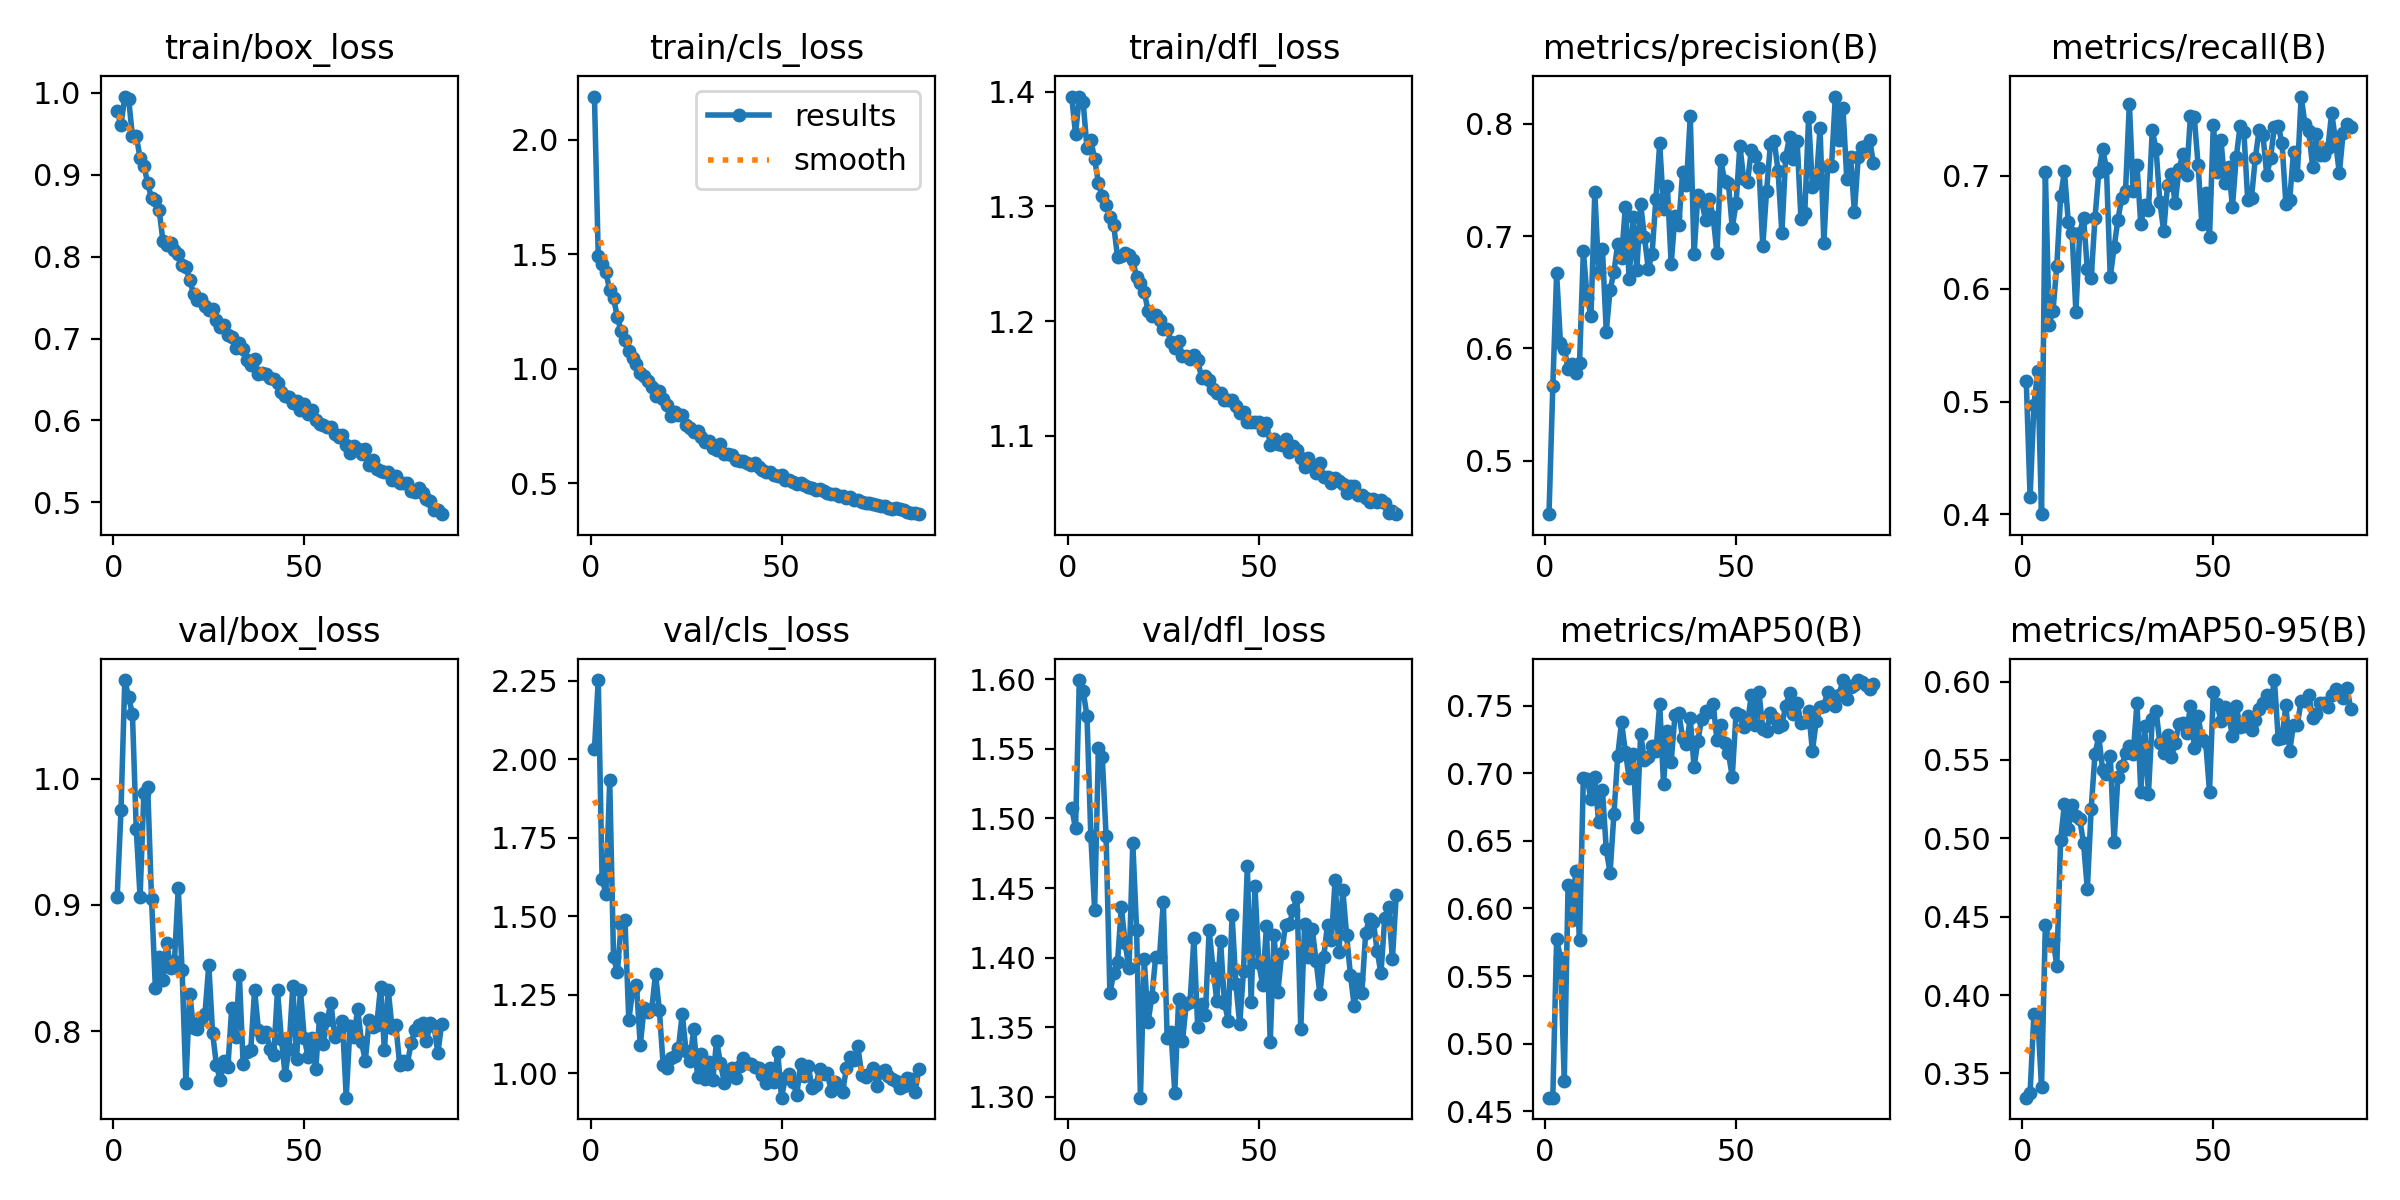

Precision-Recall Curve:


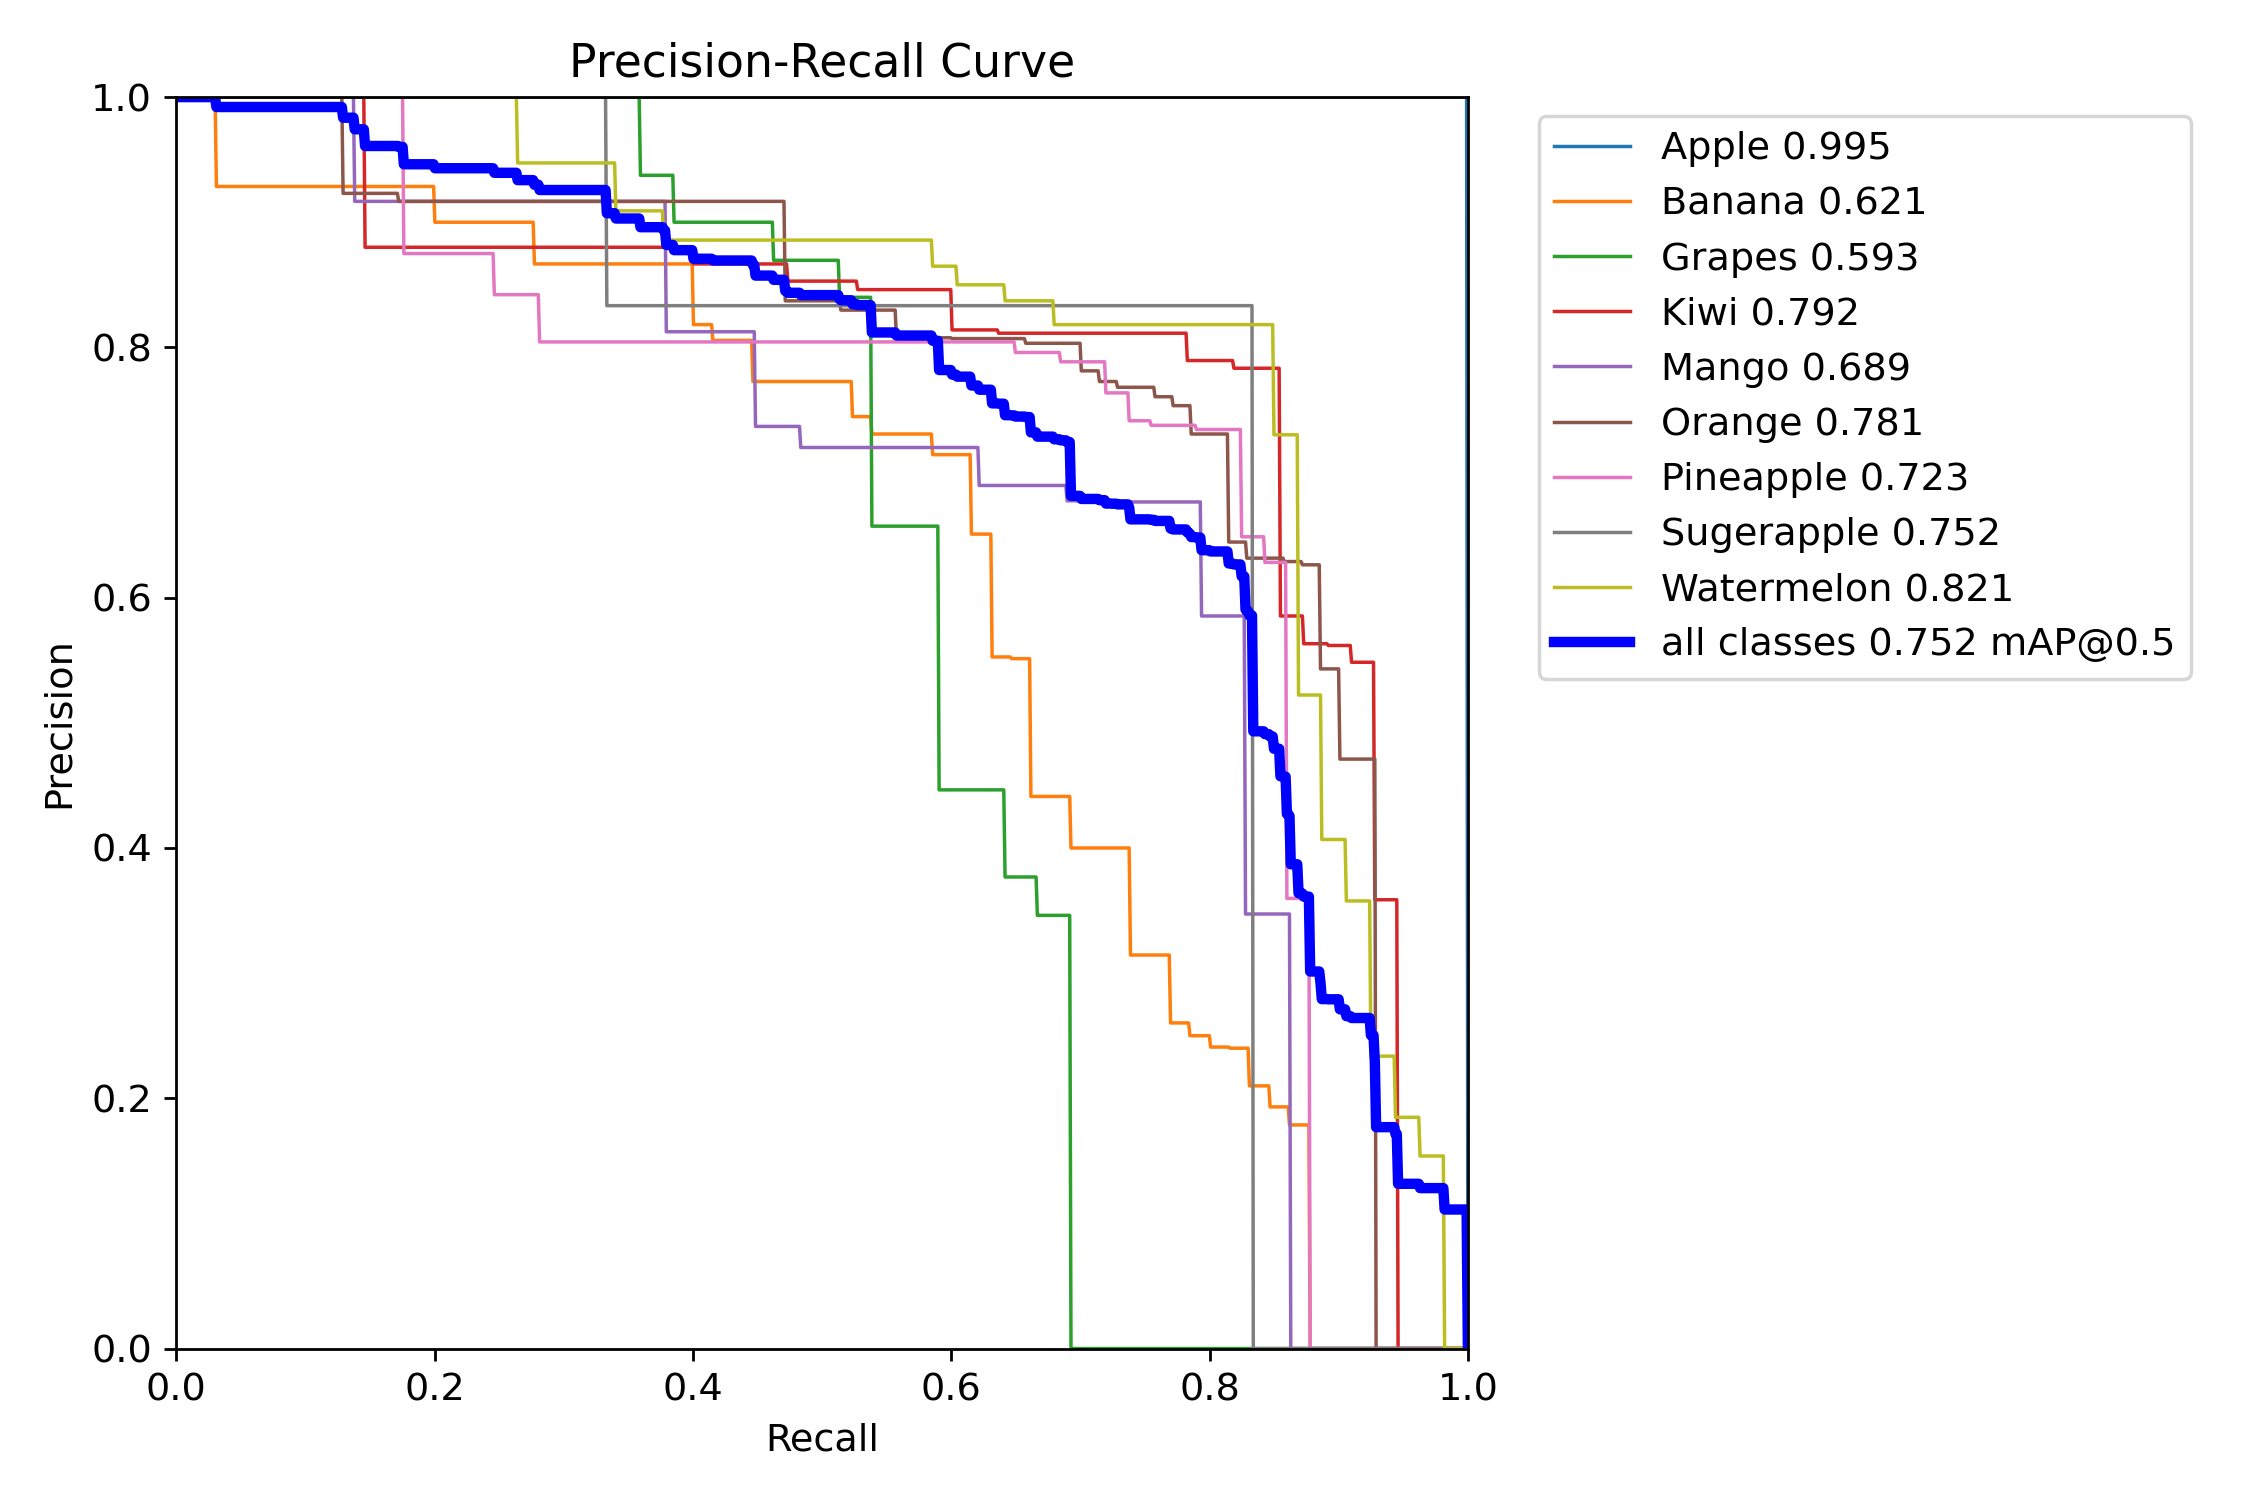

In [ ]:
from IPython.display import Image, display

print("Confusion Matrix:")
display(Image('/content/runs/detect/fruit_detector_final/confusion_matrix.png'))

print("Training Curves (loss, mAP per epoch):")
display(Image('/content/runs/detect/fruit_detector_final/results.png'))

print("Precision-Recall Curve:")
display(Image('/content/runs/detect/fruit_detector_final/BoxPR_curve.png'))

In [ ]:
from google.colab import files
files.download('/content/runs/detect/fruit_detector_final/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>